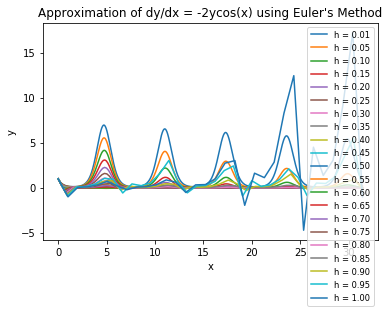

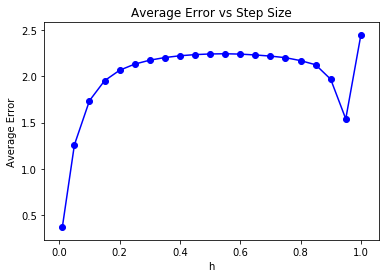

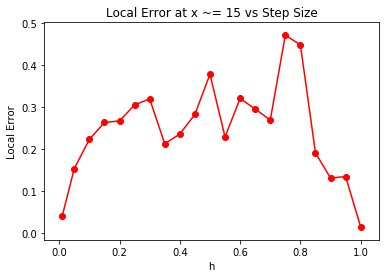

In [26]:
import numpy as np
import matplotlib.pyplot as plt

x_start, x_end = 0, 10 * np.pi

def defineParameters(h):
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 1 # y(0) = 1
    
    return num_steps, x_values, y_values

# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y * np.cos(x)

# Exact solution
def exactf(x):
    return np.exp(-2 * np.sin(x))

h_values = np.arange(0, 1.05, 0.05)
h_values[0] = .01
avgError = np.zeros(len(h_values))
localError = np.zeros(len(h_values))

for index, h in enumerate(h_values):
    num_steps, x_values, y_values = defineParameters(h)
    
    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    
    # Average Error
    y_exact = exactf(x_values)
    avgError[index] = np.mean(np.abs((y_exact - y_values)))
    
    # Local error at x = 15
    idx = np.argmin(np.abs(x_values - 15))
    x_local = x_values[idx]
    localError[index] = np.abs(exactf(x_local) - y_values[idx])

    plt.plot(x_values, y_values, label=f'h = {h:.2f}')

# Plotting Euler's Method
plt.xlabel('x')
plt.ylabel('y')
plt.title(f"Approximation of dy/dx = -2ycos(x) using Euler's Method")
plt.legend(fontsize = 'small')
plt.show()

# Plotting average error
plt.plot(h_values, avgError, 'b-')
plt.scatter(h_values, avgError, color = 'blue')
plt.xlabel('h')
plt.ylabel('Average Error')
plt.title('Average Error vs Step Size')
plt.show()

# Plotting local error
plt.plot(h_values, localError, 'r-')
plt.scatter(h_values, localError, color = 'red')
plt.xlabel('h')
plt.ylabel('Local Error')
plt.title('Local Error at x ~= 15 vs Step Size')
plt.show()

From the first graph, we can notice that with larger step sizes, the solutions undergo amplitude distortion because error for Euler's Method is proportional to the step size h. From the second graph, while average errors generally increase over time, there are some points where the solutions oscillate up and down so much that the average error coincidentally becomes closer to the exact solution. From the third graph, local error appears to change erratically, because solutions with different step sizes can sometimes phase shift relative to each other, which creates the variation.

## Homework 7 Addendum:

To perform stability analysis, we can plug f(x,y) = -2ycos(x) into yn+1 = yn+hf(x,y) to get yn+1 = yn(1-2hcos(x)). Therefore, lambda is the amplification factor, 1-2hcos(x). For Euler's Method to be stable, |lambda| <= 1, so |1-2hcos(x)| <= 1 is the stability condition for f(x,y) = -2ycos(x). Since lambda is dependent on x, stability varies with each step, so Euler's Method may alternate between stability and instability regardless of choice of h.